In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [10]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\anomalous dim\\cusp\\cusp.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaH.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaB.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammaS.jl")
Main.include("..\\anomalous dim\\non-cusp\\gammav.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\soft\\soft.jl")
Main.include("..\\sigma.jl")
Main.include("..\\error.jl")
Main.include("..\\fixed order\\perturbation.jl")
Main.include("..\\fixed order\\SCET.jl")
Main.include("..\\fixed order\\non-singular.jl")
Main.include("..\\fit.jl")
Main.include("..\\NP.jl")
Main.include("..\\renormalon.jl")

<PyCall.jlwrap renormalon_MS_func>

Range Choice

In [11]:
χ_lower = 115
χ_upper = 165

Read Data

In [13]:
dataset_qua = ["OPAL", "MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    STAT = df["STAT"]
    SYS = df["SYS"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "STAT":STAT, "SYS":SYS})
    df_ss[name] = df1

dataset_names = ["SLD","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]
df = df_qua
df.update(df_ss)

#---------------------------------------------------------------------------------

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    STAT[name] = np.array(df_truncated[name]["STAT"])
    SYS[name] = np.array(df_truncated[name]["SYS"])

Q_list = {}

Q_list["TASSO_140"]=14.0
Q_list["TASSO_220"]=22.0
Q_list["TASSO_348"]=34.8
Q_list["MARKII"]   =29.0
Q_list["TASSO_435"]=43.5
Q_list["TOPAZ_533"]=53.3
Q_list["TOPAZ_595"]=59.5
Q_list["SLD"]      =91.2
Q_list["OPAL"]=91.2
Q_list["DELPHI"]=91.2

Chi-Square calculation

In [24]:
def CHI2_func(DELTA,STAT,SYS):
    ERROR = (STAT**2+SYS**2)**0.5
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [15]:
def CHI2_func(DELTA,STAT,SYS):

    #Build Error Matrix
    l = len(DELTA)
    V = np.zeros((l, l))
    for i in range(l):
        for j in range(l):
            if i == j:
                V[i, j] = (STAT[i] ** 2) + min(SYS[i] ** 2, SYS[j] ** 2)
            else:
                V[i, j] = min(SYS[i] ** 2, SYS[j] ** 2)
    V_inv = np.linalg.inv(V)

    #Calculate Chi2
    chi_squared = np.dot(DELTA, np.matmul(V_inv, DELTA))
    return chi_squared

In [16]:
def DELTA_func(ylist,PRED):

    l = len(ylist)
    N = len(PRED)
    theory=np.zeros(l)
    for i in range(l):
        sum=0
        for j in range(N):
            sum=sum+np.nan_to_num(PRED[j][i],nan=0.0)
        theory[i]=sum/N
    return theory - ylist

Define Objective

In [21]:
import sys
def objective(params, df, Q_list, dataset_names, if_renormalon):

    #----------
    XLL="N3LL'"
    XLO=2 # 1:LO 2:NLO
    N=9
    #----------

    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist_mid=np.array(df[name]["CHI"])
        binsize=abs(xlist_mid[1]-xlist_mid[0]) # Evenly sized bins assumed
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        STAT_list=np.array(df[name]["STAT"])
        SYS_list=np.array(df[name]["SYS"])

        l = len(xlist_mid)
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters, Ω1=Ω1)
                DELTA =  DELTA_func(ylist,PRED)
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, Ω1=Ω1)              
                DELTA =  DELTA_func(ylist,PRED)               
        else:
            parameters = params_noαs
            if len(parameters) > 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters)                
                DELTA =  DELTA_func(ylist,PRED)             
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO)              
                DELTA =  DELTA_func(ylist,PRED)              

        chi_square = CHI2_func(DELTA,STAT_list,SYS_list)
        chi2 = chi2 + chi_square

    return chi2/length

Define minimization related

In [22]:
class ProgressCallback:
    def __init__(self, df, Q_list, dataset_names, if_renormalon):
        self.df = df
        self.Q_list = Q_list
        self.dataset_names = dataset_names
        self.if_renormalon = if_renormalon
        self.iteration = 0
        #self.pbar = tqdm(total=200)

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.df, self.Q_list, self.dataset_names, self.if_renormalon)
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()
        #self.pbar.update()

class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin

Test

In [27]:
objective([0.1179,1.63,-0.853,-0.048], df_truncated, Q_list, dataset_names, False)

1.1293263644649902

In [19]:
if_renormalon = False

Global

In [50]:
bounds = [ #[ 0.11 , 0.126], # αs
           #[-0.0  , 1.0  ], # Ω1
           [-1.0  , 1.0  ], # a1
           [-1.0  , 1.0  ], # a2
           [-1.0  , 1.0  ], # a3         
        ]

n_points = 17
n_parameters = len(bounds)

points = [np.linspace(bound[0], bound[1], n_points) for bound in bounds]
mesh = np.meshgrid(*points, indexing='ij')
params = [list(coord) for coord in zip(*(x.ravel() for x in mesh))]
print(params)

[[-1.0, -1.0, -1.0], [-1.0, -1.0, -0.875], [-1.0, -1.0, -0.75], [-1.0, -1.0, -0.625], [-1.0, -1.0, -0.5], [-1.0, -1.0, -0.375], [-1.0, -1.0, -0.25], [-1.0, -1.0, -0.125], [-1.0, -1.0, 0.0], [-1.0, -1.0, 0.125], [-1.0, -1.0, 0.25], [-1.0, -1.0, 0.375], [-1.0, -1.0, 0.5], [-1.0, -1.0, 0.625], [-1.0, -1.0, 0.75], [-1.0, -1.0, 0.875], [-1.0, -1.0, 1.0], [-1.0, -0.875, -1.0], [-1.0, -0.875, -0.875], [-1.0, -0.875, -0.75], [-1.0, -0.875, -0.625], [-1.0, -0.875, -0.5], [-1.0, -0.875, -0.375], [-1.0, -0.875, -0.25], [-1.0, -0.875, -0.125], [-1.0, -0.875, 0.0], [-1.0, -0.875, 0.125], [-1.0, -0.875, 0.25], [-1.0, -0.875, 0.375], [-1.0, -0.875, 0.5], [-1.0, -0.875, 0.625], [-1.0, -0.875, 0.75], [-1.0, -0.875, 0.875], [-1.0, -0.875, 1.0], [-1.0, -0.75, -1.0], [-1.0, -0.75, -0.875], [-1.0, -0.75, -0.75], [-1.0, -0.75, -0.625], [-1.0, -0.75, -0.5], [-1.0, -0.75, -0.375], [-1.0, -0.75, -0.25], [-1.0, -0.75, -0.125], [-1.0, -0.75, 0.0], [-1.0, -0.75, 0.125], [-1.0, -0.75, 0.25], [-1.0, -0.75, 0.375], 

In [85]:
chi2_list = []
for parameters in tqdm(params):
    parameters.insert(0,0.118)
    chi2_list.append(objective(parameters, df_truncated, Q_list, dataset_names, if_renormalon))
min_chi2 = min(chi2_list)
best_params = params[chi2_list.index(min_chi2)]
print("min_chi2/dof",min_chi2,"best_params",best_params)

100%|██████████| 289/289 [01:52<00:00,  2.56it/s]

min_chi2/dof 4.820033419497693 best_params [0.118, 0.625, 0.25]


Local then hopping

In [51]:
initial_params = [0.1158,0.0,0.557] #best_params

bounds = [ [0.1 , 0.14], # αs
           #[-1.0 , 1.0  ], # Ω1
            [-3.0, 3.0  ], # a1
            [-3.0, 3.0  ], # a2
           #[-3.0, 3.0  ], # a3         
        ]

bounds_T = [list(t) for t in zip(*bounds)]

progress_callback = ProgressCallback(df_truncated, Q_list, dataset_names, if_renormalon)

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds,
    "args": (df_truncated, Q_list, dataset_names, if_renormalon),
    "options": {'maxiter': 100, 'disp': True},
    "callback": progress_callback
}

result = basinhopping(
    objective,
    initial_params,
    minimizer_kwargs=minimizer_kwargs,
    niter=0,
    accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
)

optimal_params = result.x
print(f"Optimal parameters: {optimal_params}")

Iteration: 1, Params: [0.11637301 0.07103484 0.61484604], Chi2/dof: 1.6042292039300343
Iteration: 2, Params: [0.11558605 0.07646219 0.61922269], Chi2/dof: 1.588011657509493
Iteration: 3, Params: [0.11563189 0.0768652  0.61955548], Chi2/dof: 1.5876703884516594
Iteration: 4, Params: [0.1156304  0.07839403 0.62080467], Chi2/dof: 1.5873456300350706
Iteration: 5, Params: [0.11556448 0.08200572 0.62375118], Chi2/dof: 1.5869163774379165
Iteration: 6, Params: [0.11548143 0.08471725 0.62595873], Chi2/dof: 1.5867361431880727
Iteration: 7, Params: [0.11544674 0.08540716 0.6265111 ], Chi2/dof: 1.5867098628839484
Iteration: 8, Params: [0.11544353 0.08536319 0.62647194], Chi2/dof: 1.5867087191986051
Iteration: 9, Params: [0.11544381 0.08532951 0.62644287], Chi2/dof: 1.5867086201056335
Iteration: 10, Params: [0.1154443  0.08529155 0.62640678], Chi2/dof: 1.5867083956463075
Iteration: 11, Params: [0.11544567 0.08520499 0.62631109], Chi2/dof: 1.5867074901139202
Iteration: 12, Params: [0.11544804 0.08509

In [7]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000014d8d6468c0>

Plot

In [18]:
xlist = np.pi/180*np.linspace(χ_lower,180, 100, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    if if_renormalon: 
        Ω1 = params_noαs[0]
        parameters = params_noαs[1:]  
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", parameters=parameters, Ω1=Ω1)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", Ω1=Ω1)            
    else:
        parameters = params_noαs
        if len(parameters) > 0:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'", parameters=parameters)
        else:
            v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL="N3LL'")      

    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

[-0.14211993 -0.00234558  0.84665408]


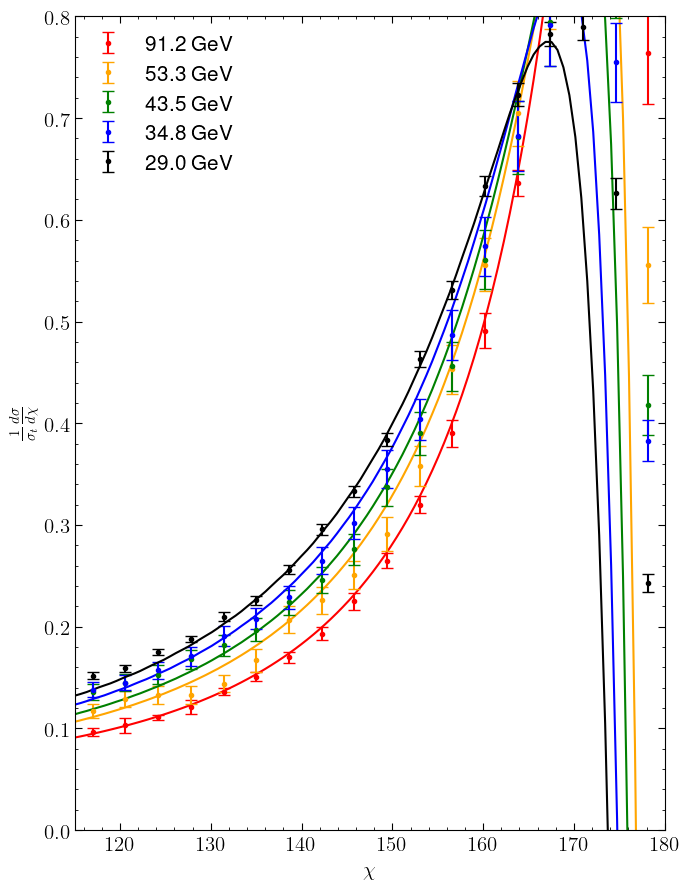

In [19]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","green","blue","black"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0,0.8)
plt.xlim(χ_lower,180)

plt.tight_layout()  
plt.show()

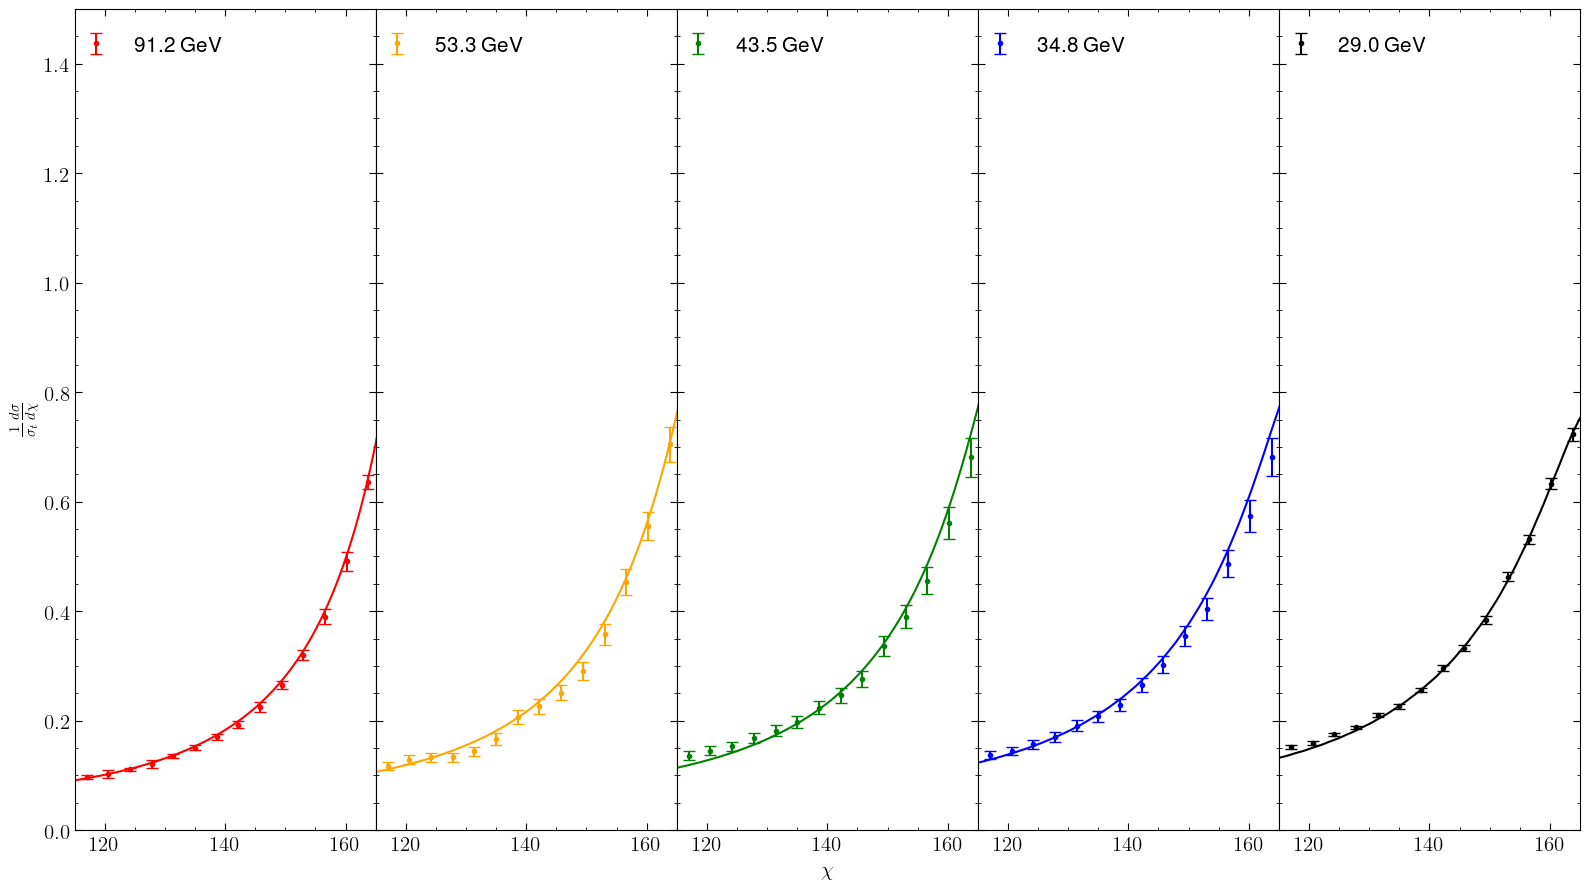

In [20]:
fig, [ax1,ax2,ax3,ax4,ax5] = plt.subplots(1, 5, figsize=(16, 9),sharex=True, sharey=True) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","green","blue","black"]
ax_list = [ax1,ax2,ax3,ax4,ax5]

i=0
for name in dataset_names:
    ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[i])
    i=i+1

ax3.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.55, 0.99))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.0, 1.5)
plt.xlim(χ_lower,165)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

Old method

In [256]:
chi2 = 0
length = 0

chi2_list = {}
params=optimal_params

XLL="N3LL'"

chi2 = 0
length = 0
    
αs = params[0]
params_noαs = params[1:]

for name in dataset_names:

    xlist=χ[name]
    ylist=EEC[name]
    errlist=ERROR[name]

    residuals=[]
    l = len(xlist)
    length = length + l

    if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL, parameters=parameters, Ω1=Ω1) - ylist)/errlist
            else: 
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL, Ω1=Ω1) - ylist)/errlist
    else:
            parameters = params_noαs
            if len(parameters) > 0:
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL, parameters=parameters) - ylist)/errlist
            else: 
                residuals = (Main.model(xlist=xlist, αs=αs, Q=Q_list[name], XLL=XLL) - ylist)/errlist 

    chi_square = np.sum(np.square(residuals))
    chi2 = chi2 + chi_square
    chi2_list[name] = chi_square/l

display(chi2_list)
display(chi2/length)

{'SLD': 0.30961435501932316,
 'TOPAZ_533': 1.2312141642487084,
 'TASSO_435': 0.9374218367643496,
 'TASSO_348': 0.6931333085027896,
 'MARKII': 1.7571109832349308}

0.9856989295540203

New method

In [268]:
chi2_list = {}

chi2=0
length=0

for name in dataset_names:
    l = len(df_truncated[name]["CHI"])
    length=length+l
    chi2_dof = objective(optimal_params, df_truncated, Q_list, [name], if_renormalon)
    chi2_list[name] = chi2_dof
    chi2 = chi2 + chi2_dof*l
display(chi2_list)
display(chi2/length)

{'SLD': 0.656106625836345,
 'TOPAZ_533': 1.2211431351832556,
 'TASSO_435': 0.6315390489215711,
 'TASSO_348': 0.9106465683856431,
 'MARKII': 0.9238929013705482}

0.8686656559394726

In [245]:
average_error={}

for name in dataset_names:
    l = len(xlist)
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'SLD': 0.0023,
 'TOPAZ_533': 0.0045,
 'TASSO_435': 0.0048,
 'TASSO_348': 0.0047,
 'MARKII': 0.0017}